In [52]:
# 1. Setup & Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set(font_scale=1.1)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [60]:
# 2. Load Data

df = pd.read_csv("fmcg_sales_marketing_profitability_2023_2025.csv")

# Basic info
print("Dataset Overview")
print("="*70)
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset Overview
Rows: 18240 | Columns: 27
Missing values: 0


In [54]:
# 3. Key Statistical Evidence

df["Promotion_Type"] = df["Promotion_Type"].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
df["Sales_Channel"] = df["Sales_Channel"].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

evidence_df = df.dropna(subset=["Discount_Pct", "Profit_Margin_Pct", "Promotion_Type", "Sales_Channel"]).copy()

corr = evidence_df[["Discount_Pct", "Profit_Margin_Pct"]].corr().iloc[0, 1]

promo_margin_df = (
    evidence_df.groupby("Promotion_Type", as_index=False)
    .agg(
        Avg_Profit_Margin_Pct=("Profit_Margin_Pct", "mean"),
        Count=("Profit_Margin_Pct", "size")
    )
    .round({"Avg_Profit_Margin_Pct": 2})
)

channel_discount_df = (
    evidence_df.groupby("Sales_Channel", as_index=False)
    .agg(
        Avg_Discount_Pct=("Discount_Pct", "mean"),
        Count=("Discount_Pct", "size")
    )
    .round({"Avg_Discount_Pct": 2})
)

print(f"Correlation (Discount vs Profit Margin): {corr:.2f}\n")
print("Average Profit Margin by Promotion Type:")
print(promo_margin_df.to_string(index=False))
print("\nAverage Discount by Sales Channel:")
print(channel_discount_df.to_string(index=False))

Correlation (Discount vs Profit Margin): 0.13

Average Profit Margin by Promotion Type:
    Promotion_Type  Avg_Profit_Margin_Pct  Count
      Bundle Offer                  19.15   2784
 Festival Campaign                  15.70   1531
    Flash Discount                  16.15   2140
Introductory Offer                  15.99    751
  Loyalty Cashback                  22.27   1398
          No Promo                  22.73   6741
 Seasonal Campaign                  18.71   2895

Average Discount by Sales Channel:
Sales_Channel  Avg_Discount_Pct  Count
  Distributor             15.79   3629
 Modern Trade             12.55   6219
       Online              8.86   5544
    Wholesale             18.07   2848


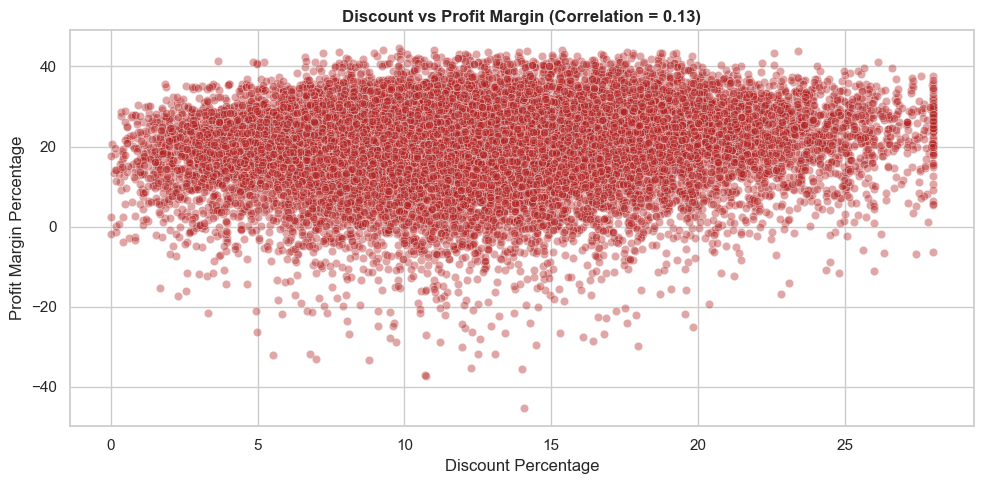

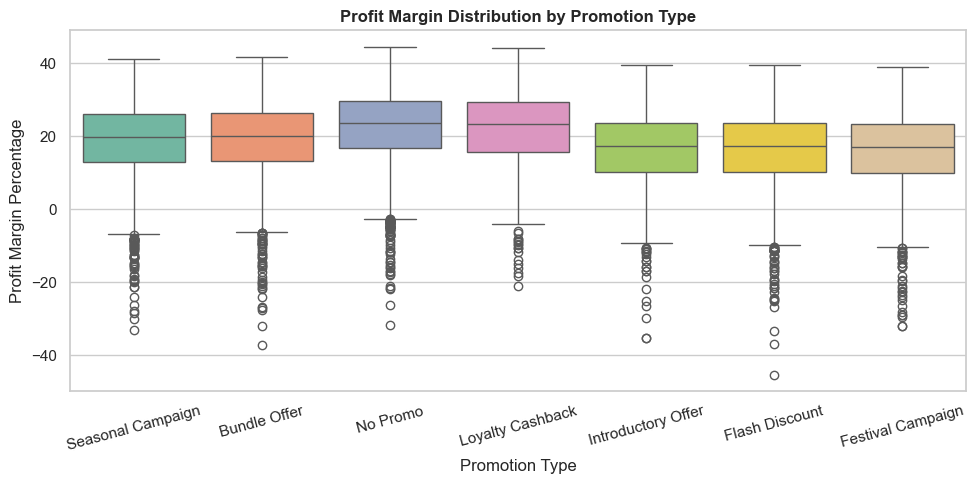

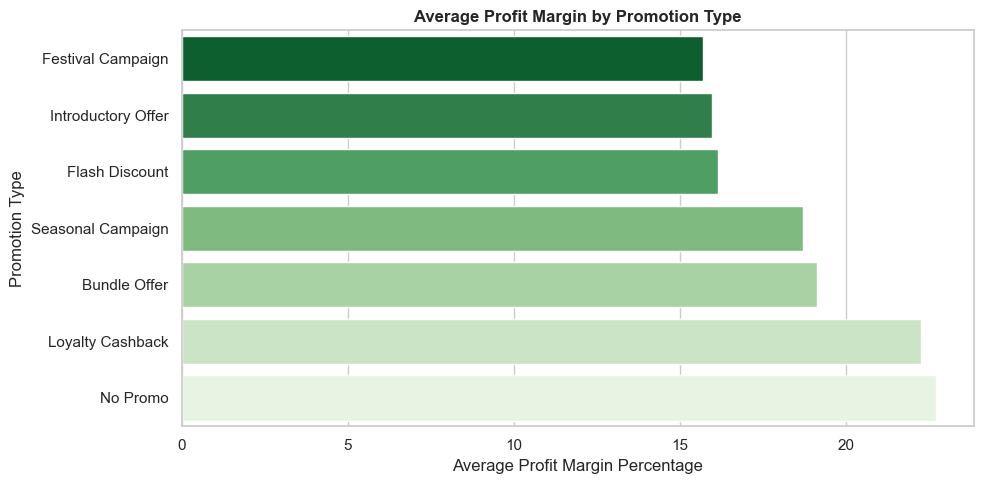

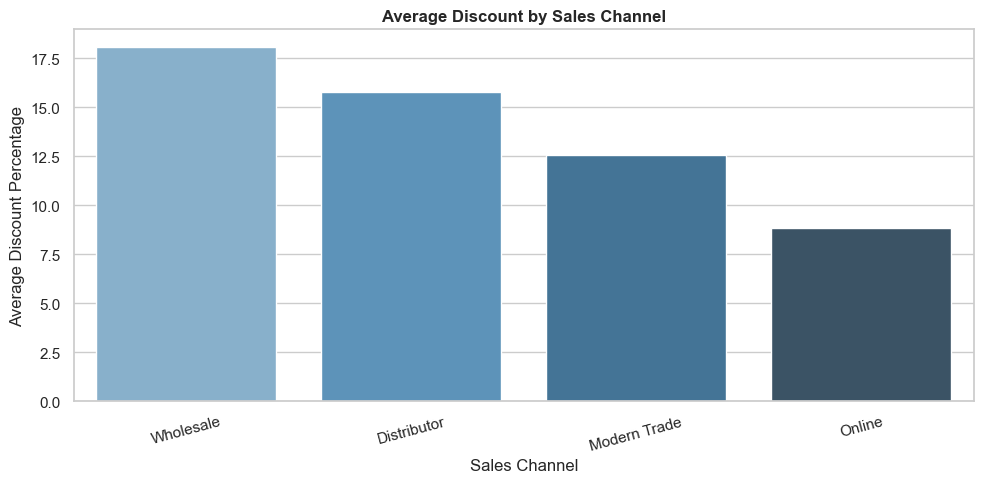

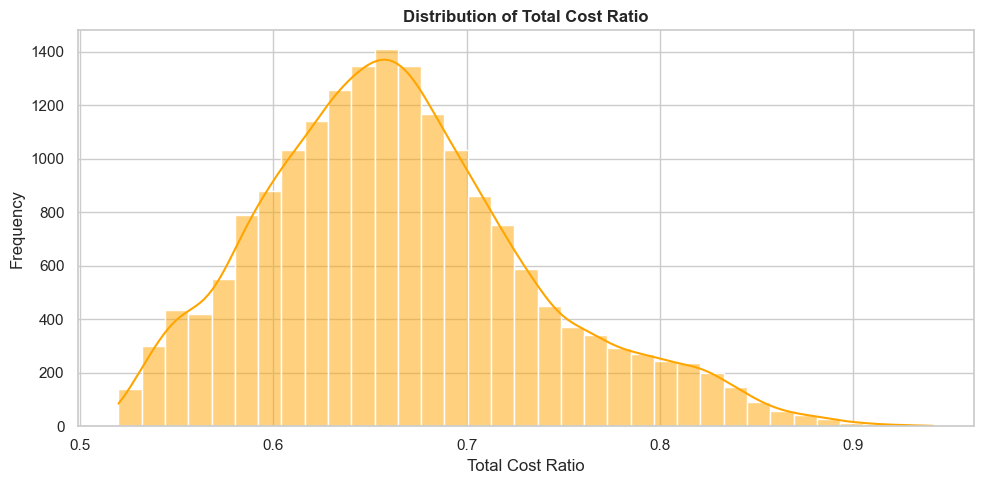

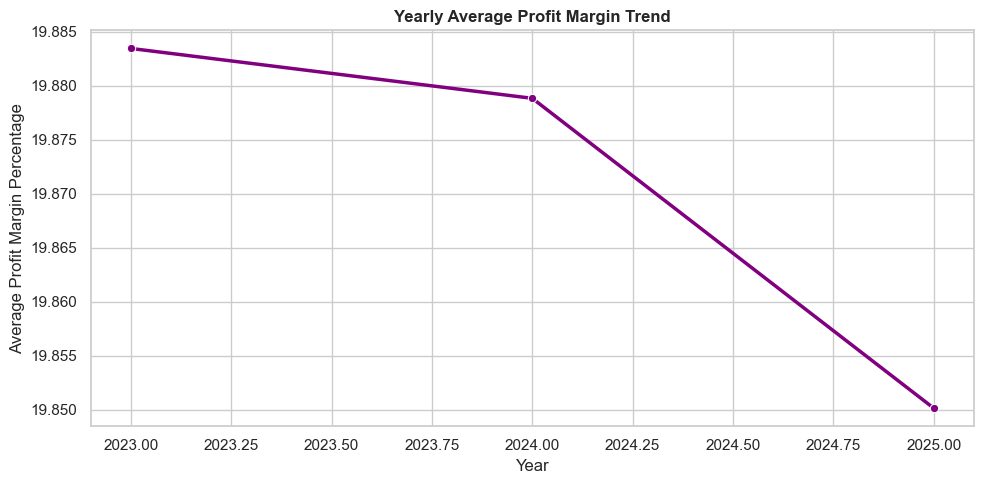

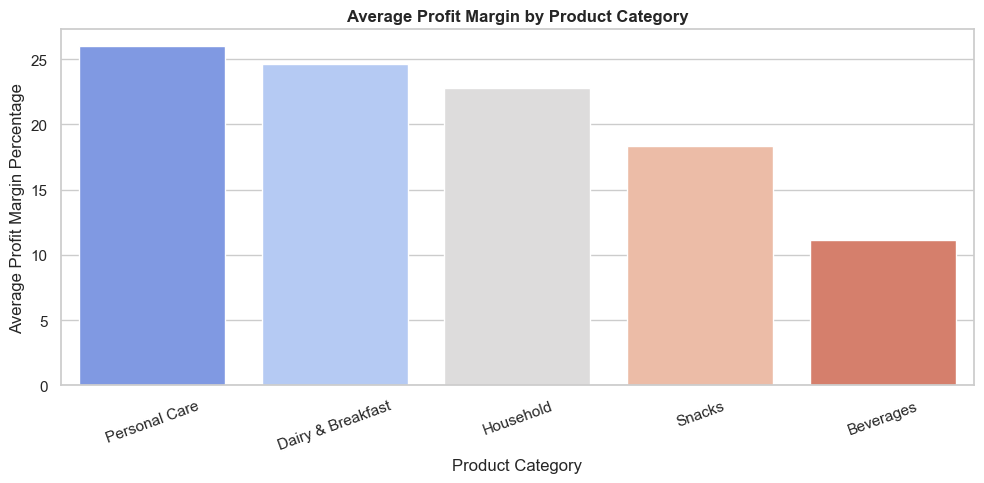

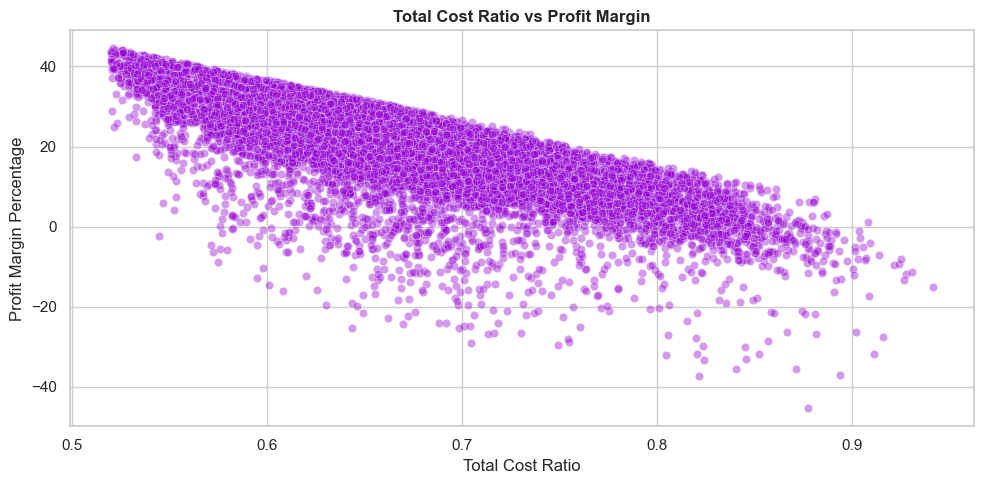

In [55]:
# 4. Visualization

import os

sns.set_theme(style="whitegrid")

# Create a copy for visualization
viz_df = evidence_df.copy()

# Ensure numeric columns are properly formatted
viz_df["COGS_USD"] = pd.to_numeric(viz_df["COGS_USD"], errors="coerce")
viz_df["Logistics_Cost_USD"] = pd.to_numeric(viz_df["Logistics_Cost_USD"], errors="coerce")
viz_df["Net_Revenue_USD"] = pd.to_numeric(viz_df["Net_Revenue_USD"], errors="coerce")
viz_df["Year"] = pd.to_numeric(viz_df["Year"], errors="coerce")

# Build cost ratio safely
cost_df = viz_df.dropna(subset=["COGS_USD", "Logistics_Cost_USD", "Net_Revenue_USD", "Profit_Margin_Pct"]).copy()
cost_df = cost_df[cost_df["Net_Revenue_USD"] != 0].copy()
cost_df["Total_Cost_Ratio"] = (cost_df["COGS_USD"] + cost_df["Logistics_Cost_USD"]) / cost_df["Net_Revenue_USD"]

# Optional: create a folder for saving figures
# os.makedirs("figures", exist_ok=True)

# 1. Discount vs Profit Margin
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=viz_df,
    x="Discount_Pct",
    y="Profit_Margin_Pct",
    alpha=0.4,
    color="firebrick"
)
plt.title(f"Discount vs Profit Margin (Correlation = {corr:.2f})", weight="bold")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit Margin Percentage")
plt.tight_layout()
plt.show()
# plt.savefig("figures/chart_1_discount_vs_margin.png", dpi=300, bbox_inches="tight")

# 2. Profit Margin Distribution by Promotion Type
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=viz_df,
    x="Promotion_Type",
    y="Profit_Margin_Pct",
    palette="Set2"
)
plt.title("Profit Margin Distribution by Promotion Type", weight="bold")
plt.xlabel("Promotion Type")
plt.ylabel("Profit Margin Percentage")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
# plt.savefig("figures/chart_2_boxplot_promotion_margin.png", dpi=300, bbox_inches="tight")

# 3. Average Profit Margin by Promotion Type
plt.figure(figsize=(10, 5))
promo_plot_df = promo_margin_df.sort_values("Avg_Profit_Margin_Pct", ascending=True)
sns.barplot(
    data=promo_plot_df,
    x="Avg_Profit_Margin_Pct",
    y="Promotion_Type",
    palette="Greens_r"
)
plt.title("Average Profit Margin by Promotion Type", weight="bold")
plt.xlabel("Average Profit Margin Percentage")
plt.ylabel("Promotion Type")
plt.tight_layout()
plt.show()
# plt.savefig("figures/chart_3_avg_margin_by_promotion.png", dpi=300, bbox_inches="tight")

# 4. Average Discount by Sales Channel
plt.figure(figsize=(10, 5))
channel_plot_df = channel_discount_df.sort_values("Avg_Discount_Pct", ascending=False)
sns.barplot(
    data=channel_plot_df,
    x="Sales_Channel",
    y="Avg_Discount_Pct",
    palette="Blues_d"
)
plt.title("Average Discount by Sales Channel", weight="bold")
plt.xlabel("Sales Channel")
plt.ylabel("Average Discount Percentage")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
# plt.savefig("figures/chart_4_avg_discount_by_channel.png", dpi=300, bbox_inches="tight")

# 5. Total Cost Ratio Distribution
plt.figure(figsize=(10, 5))
sns.histplot(
    data=cost_df,
    x="Total_Cost_Ratio",
    bins=35,
    kde=True,
    color="orange"
)
plt.title("Distribution of Total Cost Ratio", weight="bold")
plt.xlabel("Total Cost Ratio")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
# plt.savefig("figures/chart_5_cost_ratio_distribution.png", dpi=300, bbox_inches="tight")

# 6. Yearly Profit Margin Trend
year_margin_df = (
    viz_df.dropna(subset=["Year", "Profit_Margin_Pct"])
    .groupby("Year", as_index=False)["Profit_Margin_Pct"]
    .mean()
    .sort_values("Year")
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=year_margin_df,
    x="Year",
    y="Profit_Margin_Pct",
    marker="o",
    linewidth=2.5,
    color="purple"
)
plt.title("Yearly Average Profit Margin Trend", weight="bold")
plt.xlabel("Year")
plt.ylabel("Average Profit Margin Percentage")
plt.tight_layout()
plt.show()
# plt.savefig("figures/chart_6_yearly_margin_trend.png", dpi=300, bbox_inches="tight")

# 7. Average Profit Margin by Product Category
category_margin_df = (
    viz_df.dropna(subset=["Product_Category", "Profit_Margin_Pct"])
    .groupby("Product_Category", as_index=False)["Profit_Margin_Pct"]
    .mean()
    .sort_values("Profit_Margin_Pct", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=category_margin_df,
    x="Product_Category",
    y="Profit_Margin_Pct",
    palette="coolwarm"
)
plt.title("Average Profit Margin by Product Category", weight="bold")
plt.xlabel("Product Category")
plt.ylabel("Average Profit Margin Percentage")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
# plt.savefig("figures/chart_7_margin_by_category.png", dpi=300, bbox_inches="tight")

# 8. Cost Ratio vs Profit Margin
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=cost_df,
    x="Total_Cost_Ratio",
    y="Profit_Margin_Pct",
    alpha=0.4,
    color="darkviolet"
)
plt.title("Total Cost Ratio vs Profit Margin", weight="bold")
plt.xlabel("Total Cost Ratio")
plt.ylabel("Profit Margin Percentage")
plt.tight_layout()
plt.show()
# plt.savefig("figures/chart_8_cost_ratio_vs_margin.png", dpi=300, bbox_inches="tight")

In [56]:
# 5. Feature Engineering
# ================================================================
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Use cleaned data for consistency
data = evidence_df.copy()

# Ensure numeric columns are properly formatted
num_cols = [
    "COGS_USD",
    "Logistics_Cost_USD",
    "Net_Revenue_USD",
    "Marketing_Spend_USD",
    "Discount_Pct",
    "Units_Sold",
    "Profit_Margin_Pct"
]

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Create business ratio features safely
data["Total_Cost_Ratio"] = np.where(
    data["Net_Revenue_USD"] != 0,
    (data["COGS_USD"] + data["Logistics_Cost_USD"]) / data["Net_Revenue_USD"],
    np.nan
)

data["Marketing_Ratio"] = np.where(
    data["Net_Revenue_USD"] != 0,
    data["Marketing_Spend_USD"] / data["Net_Revenue_USD"],
    np.nan
)

data["Logistics_Ratio"] = np.where(
    data["Net_Revenue_USD"] != 0,
    data["Logistics_Cost_USD"] / data["Net_Revenue_USD"],
    np.nan
)

# Clean categorical variables before encoding
cat_cols = ["Sales_Channel", "Promotion_Type", "Region"]
encoders = {}

for col in cat_cols:
    data[col] = (
        data[col]
        .astype("string")
        .fillna("Unknown")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    
    le = LabelEncoder()
    data[f"{col}_Enc"] = le.fit_transform(data[col])
    encoders[col] = le

print("=" * 70)
print("Feature Engineering Summary")
print("=" * 70)
print(data[[
    "Total_Cost_Ratio",
    "Marketing_Ratio",
    "Logistics_Ratio",
    "Sales_Channel_Enc",
    "Promotion_Type_Enc",
    "Region_Enc"
]].head())

Feature Engineering Summary
   Total_Cost_Ratio  Marketing_Ratio  Logistics_Ratio  Sales_Channel_Enc  \
0          0.634282         0.117312         0.076426                  1   
1          0.572625         0.136720         0.092633                  2   
2          0.613972         0.094108         0.058740                  0   
3          0.648692         0.063009         0.045344                  3   
4          0.574499         0.110691         0.073179                  1   

   Promotion_Type_Enc  Region_Enc  
0                   6           3  
1                   0           0  
2                   6           2  
3                   5           1  
4                   4           1  



Random Forest Regression Results
Rows used for modeling: 18240
R^2 Score: 0.9987
MAE:       0.2397
RMSE:      0.3817

Feature Importance:
              Feature  Importance
2    Total_Cost_Ratio    0.578854
1     Marketing_Ratio    0.421080
3     Logistics_Ratio    0.000032
4          Units_Sold    0.000011
0        Discount_Pct    0.000009
7          Region_Enc    0.000007
6  Promotion_Type_Enc    0.000005
5   Sales_Channel_Enc    0.000001


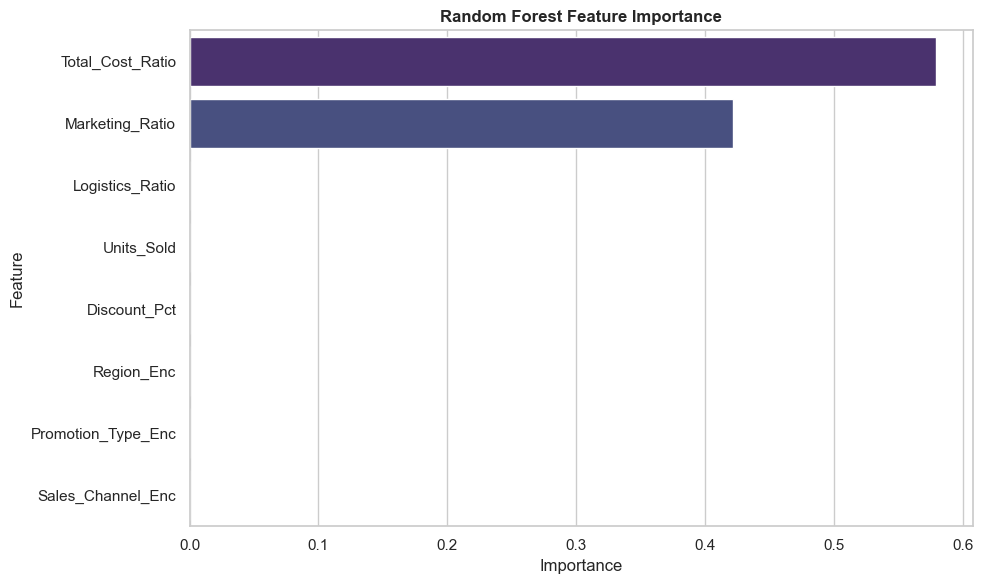

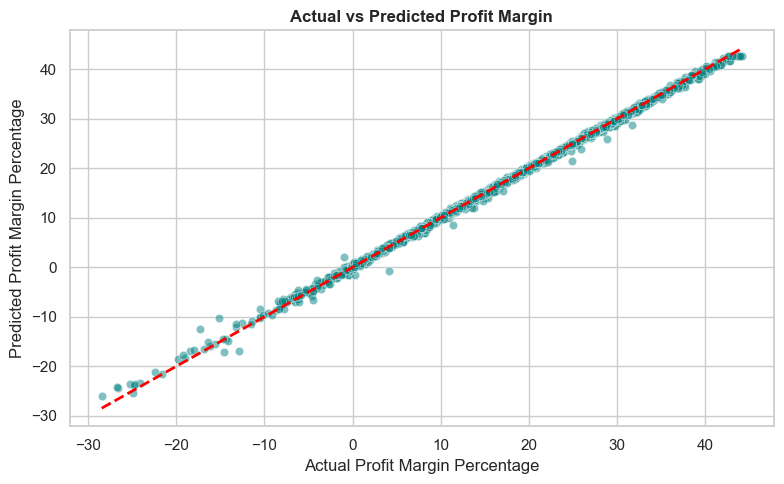

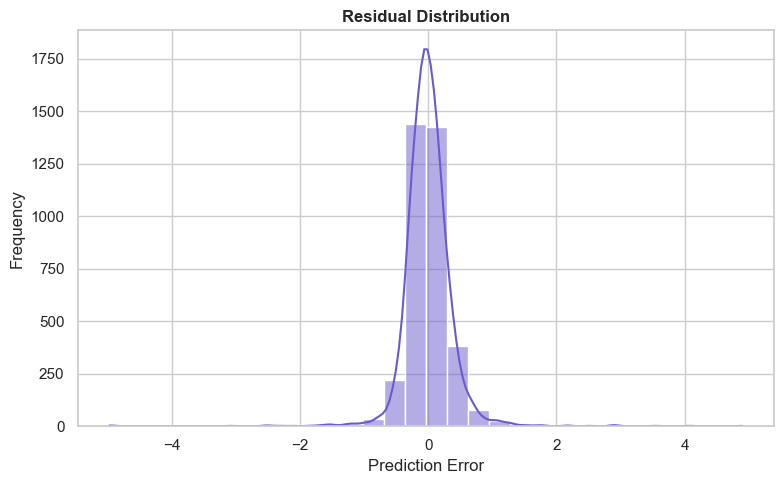

In [57]:
# 6. Modeling (Random Forest Regression)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Select features aligned with the research question
features = [
    "Discount_Pct",
    "Marketing_Ratio",
    "Total_Cost_Ratio",
    "Logistics_Ratio",
    "Units_Sold",
    "Sales_Channel_Enc",
    "Promotion_Type_Enc",
    "Region_Enc"
]

target = "Profit_Margin_Pct"

# Keep only required columns
model_df = data[features + [target]].copy()

# Drop missing values
model_df = model_df.dropna().copy()

# Define X and y
X = model_df[features]
y = model_df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "=" * 70)
print("Random Forest Regression Results")
print("=" * 70)
print(f"Rows used for modeling: {len(model_df)}")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"RMSE:      {rmse:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance", weight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Actual vs Predicted plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color="teal")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)
plt.title("Actual vs Predicted Profit Margin", weight="bold")
plt.xlabel("Actual Profit Margin Percentage")
plt.ylabel("Predicted Profit Margin Percentage")
plt.tight_layout()
plt.show()

# Residual distribution
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color="slateblue")
plt.title("Residual Distribution", weight="bold")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

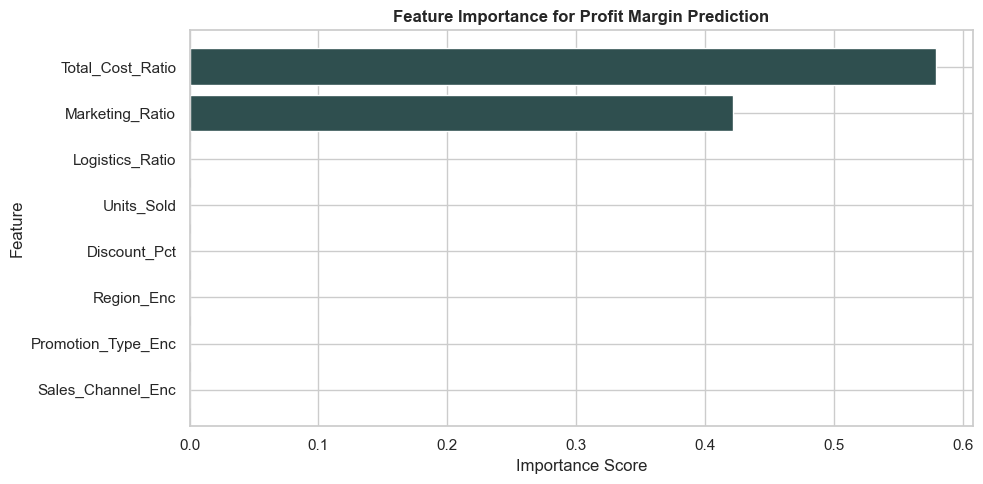

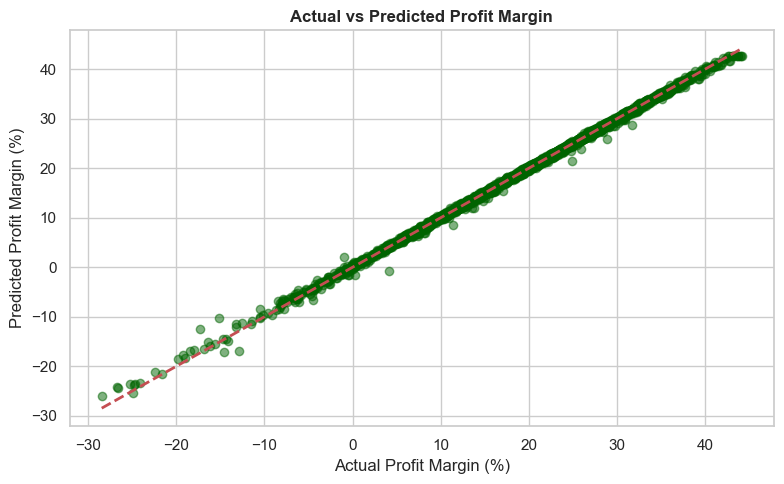

In [58]:
# 7. Model Interpretation and Prediction Check

import os

# Create folder for saving figures
os.makedirs("figures", exist_ok=True)

# Feature importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="darkslategray")
plt.title("Feature Importance for Profit Margin Prediction", weight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color="darkgreen")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2
)
plt.xlabel("Actual Profit Margin (%)")
plt.ylabel("Predicted Profit Margin (%)")
plt.title("Actual vs Predicted Profit Margin", weight="bold")
plt.tight_layout()
plt.savefig("figures/actual_vs_predicted_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Interpretation:
# The feature importance chart shows which variables contribute most to the
# Random Forest model when predicting profit margin.
# The actual vs predicted plot helps assess model performance visually:
# points closer to the diagonal line indicate better prediction accuracy.

In [59]:
# 8. Conclusion (Evidence-Based)

top_promo = promo_margin.idxmax()
top_promo_value = promo_margin.max()

top_channel = channel_discount.idxmax()
top_channel_value = channel_discount.max()

top_feature = importance_df.sort_values("Importance", ascending=False).iloc  [0]["Feature"]

if corr < 0:
    corr_direction = "negative"
else:
    corr_direction = "positive"

print("KEY INSIGHTS")

print(f"• Discount is {corr_direction}ly correlated with profit margin (r={corr:.2f}).")
print(f"• {top_promo} yields the highest average profit margin ({top_promo_value:.2f}%).")
print(f"• {top_channel} has the highest average discount rate ({top_channel_value:.2f}%).")
print(f"• {top_feature} is the most important predictor in the Random Forest model.")


KEY INSIGHTS
• Discount is positively correlated with profit margin (r=0.13).
• No Promo yields the highest average profit margin (22.73%).
• Wholesale has the highest average discount rate (18.07%).
• Total_Cost_Ratio is the most important predictor in the Random Forest model.
